# Ejemplo FEniCS inicial



Para correr en google colab ejecutar la siguientes instrucciones (https://fem-on-colab.github.io/).

In [4]:
%%capture
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

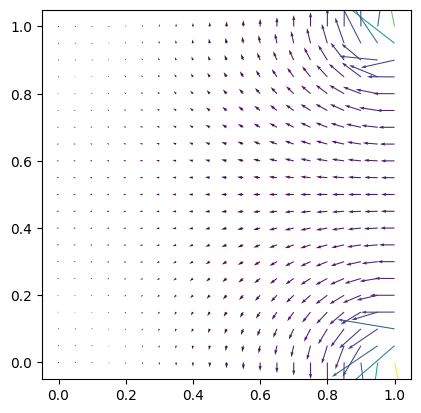

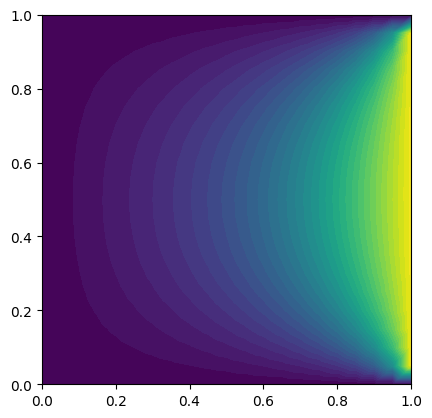

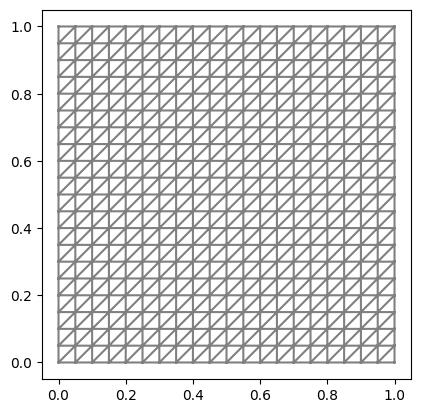

PETSc


In [6]:
from fenics import *

# Creo la malla y defino la funcion de espacio
mesh = UnitSquareMesh(20, 20)
V = FunctionSpace(mesh, 'P', 1)

# Defino las condiciones de borde
def boundary_D(x, on_boundary):
    tol = 1.E-14
    return on_boundary and near(x[0], 1., tol)

bc_der=DirichletBC(V, Constant(5.0), boundary_D)

def boundary_I(x, on_boundary):
    tol = 1.E-14
    return on_boundary and near(x[0], 0., tol)

bc_iz = DirichletBC(V, Constant(0.0), boundary_I)

def boundary_AR(x, on_boundary):
    tol = 1.E-14
    return on_boundary and near(x[1], 0., tol)

bc_arriba = DirichletBC(V, Constant(0.0), boundary_AR)

def boundary_AB(x, on_boundary):
    tol = 1.E-14
    return on_boundary and near(x[1], 1., tol)

bc_abajo = DirichletBC(V, Constant(0.0), boundary_AB)

bc = [bc_iz, bc_der, bc_arriba, bc_abajo]

#Defino la formulacion variacional
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(0.0)

#F = q(u)*dot(grad(u), grad(v))*dx - f*v*dx

#FEniCS detecta solo la forma bilineal y lineal
F = dot(grad(u), grad(v))*dx-f*v*dx
a = lhs(F)
L = rhs(F)

#Resuelvo
u = Function(V)
solve(a == L, u, bc)


vtkfile_T = File('ejemplo/123.pvd')
vtkfile_T << u

#Se puede calcular el flujo de calor (campo vectorial)
V = u.function_space() #Tomo el espacio donde vive u
mesh = V.mesh()#su malla tambien
degree = V.ufl_element().degree() #el elemento finito
W = VectorFunctionSpace(mesh, 'P', degree) #y creo un espacio con los mismos elementos de u

grad_u = project(grad(u), W) #Realizo la proyeccion
k = Constant(2.0) #Por ejemplo con conductividad termica de 0.5
flux_u = project(-k*grad(u), W)

vtkfile_Q = File('ejemplo/calor.pvd')
vtkfile_Q << flux_u


#import matplotlib.pyplot as plt
#import dolfin
#fig, axs = plt.subplots(1,1)
#dolfin.plot(flux_u)
#plt.show()

import matplotlib.pyplot as plt

plt.figure(1)
plot(flux_u)

plt.figure(2)
plot(u)

plt.figure(3)
plot(mesh)

plt.show()

#Lista de solvers y precondicionadores
#list_linear_solver_methods()
#list_krylov_solver_preconditioners()

#Imprime el solver: en este caso PETSc built in LU solver
print(parameters['linear_algebra_backend'])